# tactile-sync — a walkthrough

This notebook walks through the whole pipeline end to end: why it exists, how each
piece works, and what the results mean. Run the cells top to bottom.

**The core problem:** pairing vision with touch is hard not because either sensor is
hard, but because they run on **different clocks at different rates** and must be
*aligned* before the data is useful. That alignment is what this project builds.


## 0. Setup

We work from the project root so the relative paths (`data/`, `figures/`) resolve.
If you launched Jupyter inside `notebooks/`, the first cell steps back up one level.


In [1]:
import os
# make sure we're at the project root, not inside notebooks/
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("Working directory:", os.getcwd())

import sys
sys.path.insert(0, "src")  # so we can import the project modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


Working directory: /mnt/user-data/outputs/tactile-sync


## 1. Generate synthetic data

We don't need real recordings to develop the pipeline. `generate_synthetic.py`
fabricates two streams that imitate a real capture:

- a **sensor** stream at ~200 Hz (like an accelerometer),
- a **video** stream at ~30 fps (like a phone camera's motion signal),

and crucially they **start at different times** — a hidden offset we'll later recover.
A sharp **tap** at the very start spikes in *both* streams: that's our sync marker.


In [2]:
import generate_synthetic as gen

sensor_df, video_df, true_offset = gen.generate(seed=0)
sensor_df.to_csv("data/raw/sensor.csv", index=False)
video_df.to_csv("data/raw/video.csv", index=False)

print("sensor rows:", len(sensor_df), "| video frames:", len(video_df))
print("sensor sample rate ~", round(1/np.median(np.diff(sensor_df.t_sensor))), "Hz")
print("video sample rate ~", round(1/np.median(np.diff(video_df.t_video))), "fps")
print("(hidden) true offset between streams:", true_offset, "s")
sensor_df.head()


sensor rows: 3955 | video frames: 594
sensor sample rate ~ 200 Hz
video sample rate ~ 30 fps
(hidden) true offset between streams: 1.37 s


,t_sensor,accel_mag,label_true
0,0.000,10.087725,tap
1,0.005,10.212770,tap
2,0.010,10.384832,tap
3,0.015,10.617358,tap
4,0.020,10.925919,tap


**What to notice:** the two streams have very different row counts because they
sample at different rates. The `true_offset` is the answer key — in real life you
never get it, you have to *estimate* it. That's the next step.


## 2. Detect the sync marker

The tap is the single largest spike near the start of each stream. We search only
the first few seconds so a big *mid-recording* impact can't be mistaken for the marker.


In [3]:
import synchronize as sync

s_tap = sync.detect_sync_spike(sensor_df.t_sensor.values, sensor_df.accel_mag.values)
v_tap = sync.detect_sync_spike(video_df.t_video.values, video_df.motion_proxy.values)
print("sensor tap detected at:", round(s_tap, 3), "s")
print("video  tap detected at:", round(v_tap, 3), "s")
print("estimated offset (v_tap - s_tap):", round(v_tap - s_tap, 3), "s")


sensor tap detected at: 0.12 s
video  tap detected at: 1.47 s
estimated offset (v_tap - s_tap): 1.35 s


**Why this works:** the tap happens at the same *physical moment* in reality, so
its timestamp in each stream differs by exactly the clock offset between them.
Subtract the two and you've recovered the offset — no answer key needed.


## 3. Align and merge

Now we shift the video clock by the estimated offset and merge the two streams onto
**one common timeline** using `pandas.merge_asof`. This is an "as-of" join: each
sensor sample is matched to the *nearest* video frame within a small time tolerance.
It's the standard tool for fusing time-series that don't share timestamps.


In [4]:
merged, offset = sync.synchronize(sensor_df, video_df)
merged.to_csv("data/processed/merged.csv", index=False)

matched = merged.motion_proxy.notna().mean()
print("estimated offset:", round(offset, 3), "s   (true was", true_offset, "s)")
print("error:", round(abs(offset - true_offset)*1000, 1), "ms")
print("fraction of sensor samples matched to a video frame:", f"{matched:.1%}")
merged.head()


estimated offset: 1.35 s   (true was 1.37 s)
error: 20.0 ms
fraction of sensor samples matched to a video frame: 100.0%


,t_sensor,accel_mag,label_true,t,motion_proxy
0,0.000,10.087725,tap,0.000,NaN
1,0.005,10.212770,tap,0.005,10.504984
2,0.010,10.384832,tap,0.010,10.504984
3,0.015,10.617358,tap,0.015,10.504984
4,0.020,10.925919,tap,0.020,10.504984


**Read the error:** at 30 fps, frames are ~33 ms apart, so the best alignment you
can hope for is roughly half a frame (~17 ms). Landing within ~20 ms means the
synchronization is essentially at the resolution limit of the slower stream.


## 4. Visualize — trust your eyes before your numbers

The most important habit in sensor work: *look* at the data. If the tap spikes line
up after alignment, it worked.


Saved figures/alignment.png


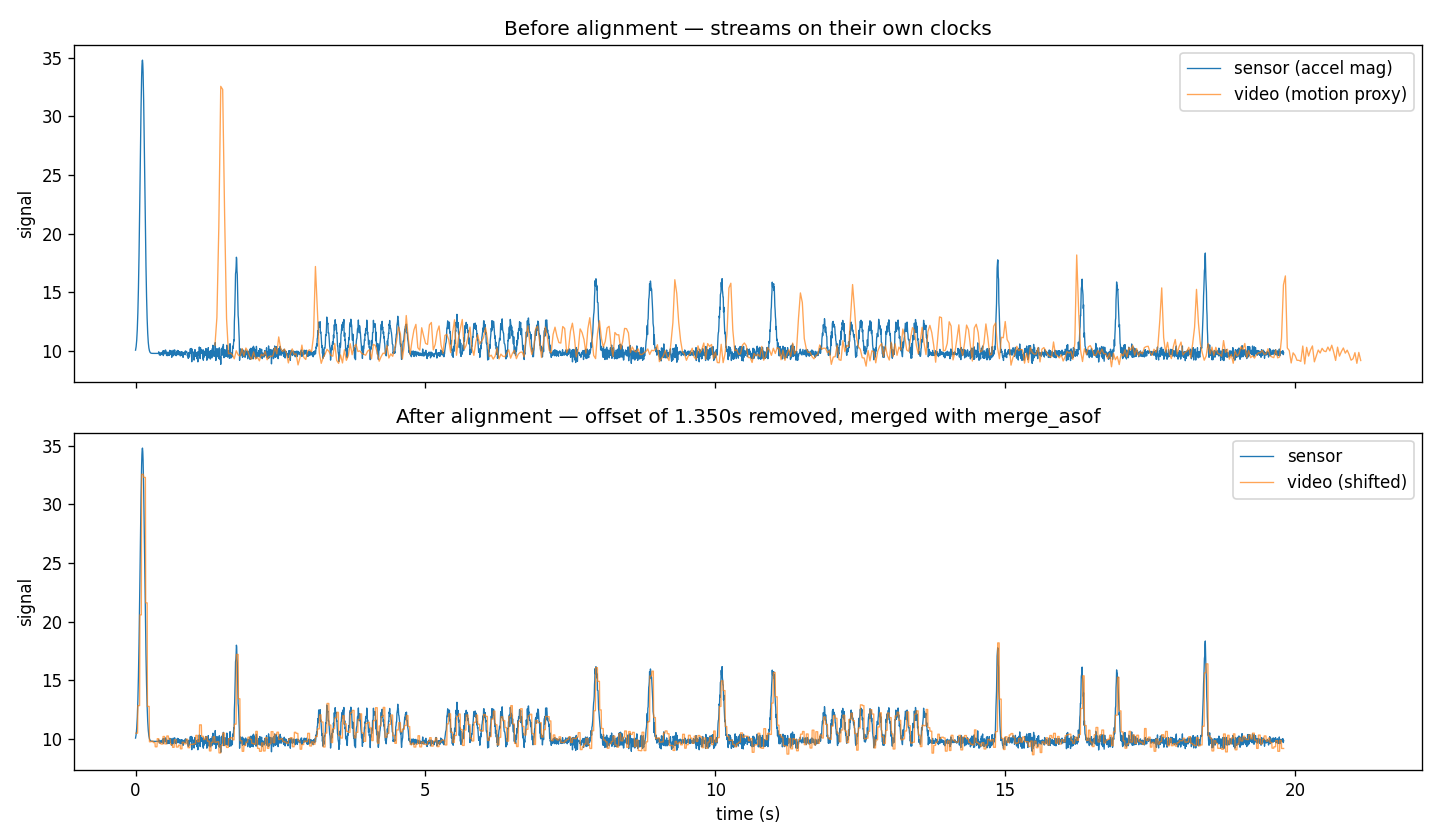

In [5]:
import visualize as viz
viz.plot_alignment(sensor_df, video_df, merged, offset)

from IPython.display import Image
Image("figures/alignment.png")


Top panel: the raw streams, visibly offset (their tap spikes are ~1.4 s apart).
Bottom panel: after alignment, the spikes snap together. That visual confirmation
is worth more than any single accuracy number.


## 5. Classify the action from the fused signal

Finally we close the loop: slice the aligned data into short windows, compute simple
features (mean, std, peak of the signal in each window), and train a random forest
to predict the action (stack / flip / screw).

We deliberately run it **twice** — sensor-only vs. sensor+video — to ask whether the
second modality helps.


In [6]:
import classify
print("sensor-only:")
acc_s = classify.run(use_video=False)
print("\nsensor+video:")
acc_sv = classify.run(use_video=True)


sensor-only:


[sensor-only] test accuracy: 93.8%  (n_windows=53)

sensor+video:


[sensor+video] test accuracy: 93.8%  (n_windows=53)


## 6. The punchline — why this matters for real tactile data

Notice sensor-only and sensor+video score **the same**. That's expected *here*:
in synthetic data the "video" channel is derived from the sensor, so it carries no
independent information.

That null result is exactly the point. A camera can't see contact force or slip;
a real **tactile glove** measures them directly. With genuine vision+touch capture,
the fused model should beat vision-alone precisely on grasp/insert tasks where
contact matters — which is the data bottleneck this whole approach is built to close.

**The synchronization core stays identical with real sensors.** Only the front-end
changes: swap the accelerometer for tactile channels, swap `motion_proxy` for real
video frames. The tap marker and `merge_asof` alignment carry over unchanged.
